# Central Limit Theorem

Broadly speaking, the central limit theorem (CLT) states that the sum of a large number of independent random variables has an approximately normal (Gaussian) distribution. It is frequently labelled as one of, if not the most, important theorems in probability and statistics. The simplest form of the CLT (known as Classical CLT) is as follows:

Let $X_1, X_2, ..., X_n$ be independent and identically (iid) distributed random variables with finite expected value $E[X_i]=\mu$ and variance $Var(X_i)=\sigma^2$.

Also, let $\bar{X}=\frac{X_1+X_2+...+X_n}{n}$. 

Then, the random variable

$$Z=\frac{\bar{X}-\mu}{\sigma/\sqrt{n}}=\frac{\sum_{i=1}^n X_i-n\mu}{\sqrt{n}\sigma},$$

converges in distribution to the standard normal random variable as $n$ goes to infinity:

$$\lim_{n\rightarrow\infty}P(Z\leq x)=\Phi(x), \text{ \qquad for all }x\in\Re,$$

where $\Phi(x)$ is the standard normal cumulative distribution function (CDF).

Interestingly, the distribution of the $X_i$'s matters not. They can be continuous, discrete or mixed random variables; the CLT holds regardless.

The CLT finds many applications. It is particularly important in hypothesis testing since it allows us to test samples from unknown or non-normal distributions using the same treatment as samples from normal distributions, provided that the sample size is sufficiently large. There are a multitude of real-world situations in which it is advantageous to use a normal distribution to approximate a random variable of interest which is a sum of a large number of independent random variables.

In [1]:
import numpy.random as rand
import numpy as np
import seaborn as sns
import pandas as pd
import math
import matplotlib.pyplot as plt
import scipy


def clt(distribution, number_rvs, points=100000):

    if distribution == "uniform":
        samples = rand.uniform(0, 1, points)
        if number_rvs > 1:
            for i in range(number_rvs - 1):
                samplesi = rand.uniform(0, 1, points)
                samples += samplesi
    
        centred = samples - (number_rvs/2)
        res = centred/np.sqrt(number_rvs/12)

    if distribution == "exponential":
        samples = rand.exponential(4, points)
        if number_rvs > 1:
            for i in range(number_rvs - 1):
                samplesi = rand.exponential(4, points)
                samples += samplesi

        centred = samples - (4*number_rvs)
        res = centred/(4*np.sqrt(number_rvs))

    if distribution == "bernoulli":
        samples = rand.binomial(1, 0.7, points)
        if number_rvs > 1:
            for i in range(number_rvs):
                samplesi = rand.binomial(1, 0.7, points)
                samples += samplesi
    
        centred = samples - 0.7*number_rvs
        res = centred/np.sqrt(0.7*0.3*number_rvs)

    return res


def clt_plot(dataframe):

    cols = dataframe.columns.tolist()
    fig, ax = plt.subplots(2, 2)

    count = 0
    for i in range(len(ax)):
        for j in range(len(ax[i])):
            ax[i][j] = sns.histplot(data=dataframe[cols[count]], ax=ax[i][j], binwidth=0.1, stat="density")
            ax[i][j].set_title("n={}".format(cols[count]))
            ax[i][j].set_xlabel("z")
            count += 1

    fig.tight_layout()  


## Samples from an exponential distribution

In this first example, the iid random variables, the $X_i$'s, will be exponentially distributed. The figure below shows the pdf of $Z=\frac{\sum_{i=1}^n X_i-n\mu}{\sqrt{n}\sigma}$ for $n=1, n=3, n=8,$ and $n=100$. With $n=1$, $Z$ has an exponential distribution as would be expected, but with $n=8$, $Z$ is already beginning to resemble a normal distribution albeit slightly skewed. With $n=100$, the distribution closely resembles the standard normal distribution.

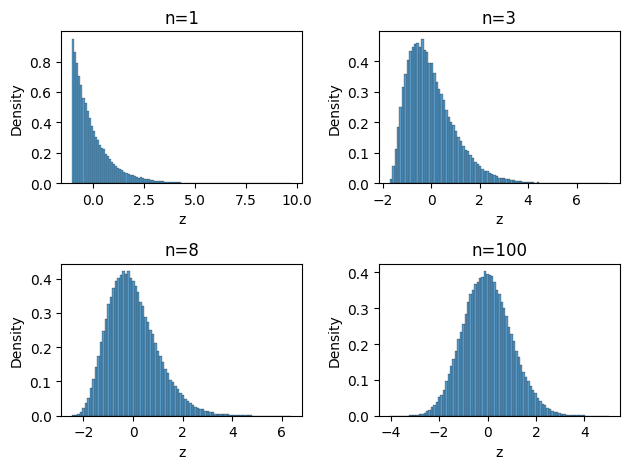

In [2]:
expcols = [1, 3, 8, 100]
expdata =  [clt("exponential", i) for i in expcols]
expdf = pd.DataFrame({expcols[i]:expdata[i] for i in range(len(expdata))})
clt_plot(expdf)

## Samples from a uniform distribution

Next we take a look at the case where the iid $X_i$'s are uniformly distributed. The figure below shows the pdf of $Z$ for $n=1, n=3, n=8,$ and $n=100$. With $n=1$, the pdf is roughly uniform and with $n=2$ it is approximately triangular. With $n=100$ the pdf closely resembles a standard normal distribution.

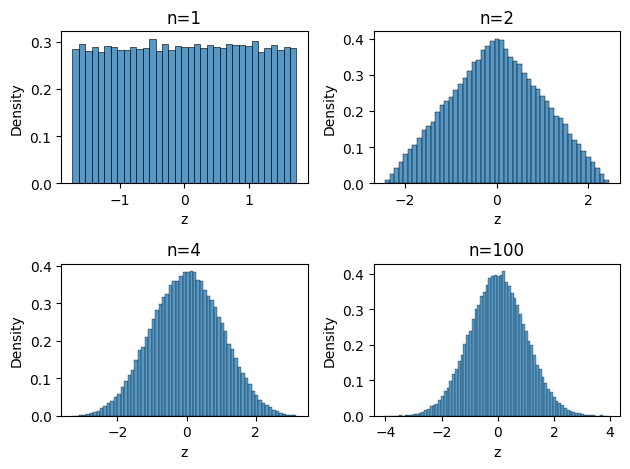

In [3]:
uni_cols = [1, 2, 4, 100]
uni_data = [clt("uniform", i) for i in uni_cols]
uni_df = pd.DataFrame({uni_cols[i]:uni_data[i] for i in range(len(uni_data))})

clt_plot(uni_df)

## Samples from a Bernoulli distribution

Finally, we look at the case where the $X_i$'s are Bernoulli random variables. The figure below shows the pmf of $Z$ for $n=1, n=15, n=100,$ and $n=200$. With $n=1$, $Z$ has the pmf of a binomial distribution with $p=0.7$ which is the value we have decided on. With $n=15$, the pmf is starting to resemble a skewed standard normal distribution. With $n=200$, the resemblance to the standard normal distribution in more apparent.

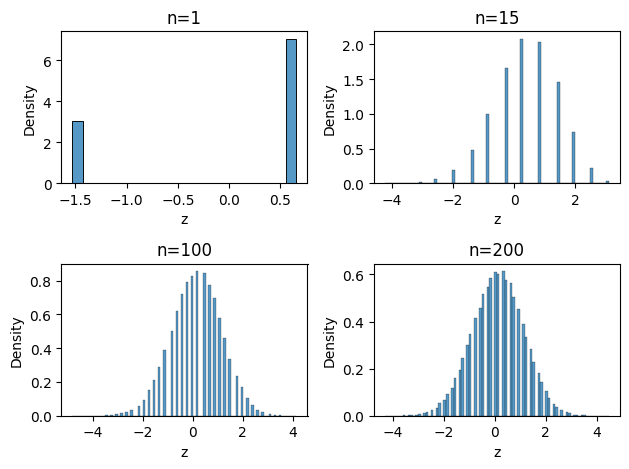

In [4]:
bern_cols = [1, 15, 100, 200]
bern_data = [clt("bernoulli", i) for i in bern_cols]
bern_df = pd.DataFrame({bern_cols[i]:bern_data[i] for i in range(len(bern_data))})

clt_plot(bern_df)

Whilst the CLT tells us that $Z=\frac{\sum_{i=1}^n X_i-n\mu}{\sqrt{n}\sigma}$ will eventually converge in distribution to the standard normal distribution for any $X_i$'s, we can see from the above examples that convergence occurs at different rates for different $X_i$'s. For example, the pdf of four summed uniform random variables bears more resemblance to the standard normal distribution than the pdfs of eight summed exponential random variables, or 15 summed Bernoulli random variables, respectively. In general, the speed of convergence is heavily dependent on the shape of the distribution of the $X_i$'s; symmetric distributions converge more quickly than skewed distributions.

## Intuition - Convolution

An important result in probability theory aserts that the pdf (for continuous random variables) of the sum of two or more independent random variables is equal to the convolution of their individual distributions. That is, for the sum $Z=X+Y$, where $X$ and $Y$ are independent random variables, the pdf of $Z$ is given by

$$f_Z(x)=\int^\infty_\infty f_X(x) f_Y(z-x) dx = (f_X * f_Y)(z)$$

Therefore, the pdf of the sum of independent random variables that appears in the CLT is equivalent to the repeated convolution of the pdf of the random variables

$$f_{\sum_i^n X_i}(x)=(f_1*f_2*...*f_n)(x),$$

where $f_i$ is the pdf of $X_i$.

In [5]:
def uniform_convolution(n):

    x = np.linspace(0, 1, 1000)
    uniform = scipy.stats.uniform()

    if n == 0:
        return uniform.pdf(x)
    
    conv = scipy.signal.convolve(uniform.pdf(x), uniform.pdf(x))    
    if n > 1:
        for i in range(n-1):
            convi = scipy.signal.convolve(uniform.pdf(x), conv)
            conv = convi

        return convi
    
    return conv


def plot_convoluted_pdfs(ns):

    rows = math.ceil(len(ns)/2)
    fig, ax = plt.subplots(rows, 2)

    data = {n:uniform_convolution(n) for n in ns}
    
    count = 0
    for i in range(len(ax)):
        for j in range(len(ax[i])):
            ax[i][j] = sns.lineplot(data=data[ns[count]], ax=ax[i][j])
            ax[i][j].set_title("number of convolutions={}".format(ns[count]))
            ax[i][j].set_xticks([])
            ax[i][j].set_yticks([])
            count += 1

    fig.tight_layout() 

Below we have plots of the pdf of the uniform distribution before and after a number of convolutions with itself. After only a few convolutions the pdf is already starting to resemble a normal distribution, with the convolution operation supplying a smoothing effect.

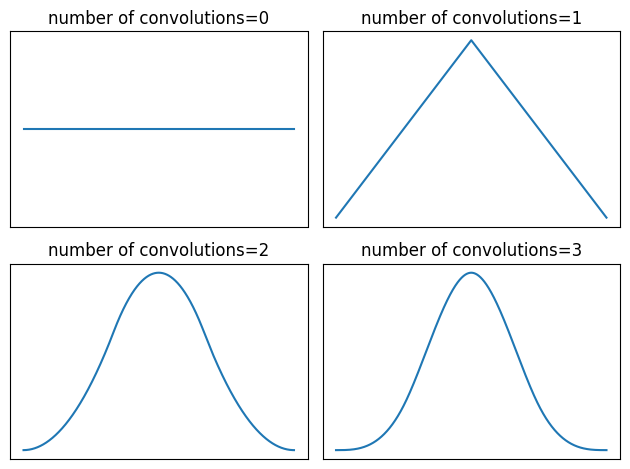

In [6]:
plot_convoluted_pdfs([0, 1, 2, 3])

## Central Limit Theorem for non-identical random variables

A more general form of the CLT is stated as follows:

Let $X_1, X_2, ..., X_n$ be indpependent (but not necessarily identically) distributed random variables. The random variable $X_i$ has expectation $E[X_i]=\mu_i$ and variance $Var(X_i)=\sigma_i^2$.

The random variable

$$Z=\frac{\sum^n_{i=1} X_i}{n},$$

converges in distribution to a normal distribution with mean $\sum^n_{i=1} \mu_i/n$ and variance $\sum^n_{i=1} \sigma_i^2/n^2$.

In [9]:
def gen_clt_plot(number_rvs, points, bins):

    distributions = ["uniform", "normal", "exponential"]
    dist_sum = np.zeros(points)
    tot_mean = 0
    tot_var = 0

    for i in range(number_rvs):
        distribution = rand.choice(distributions)
        if distribution == "uniform":
            lower_bound = rand.uniform(0, 50)
            delta = rand.uniform(1, 10)
            upper_bound = lower_bound + delta
            uni_sample = rand.uniform(lower_bound, upper_bound, points)
            dist_sum += uni_sample
            tot_mean += (lower_bound + upper_bound)/2
            tot_var += delta**2/12

        if distribution == "normal":
            mean = rand.uniform(0, 60)
            std_dev = rand.uniform(0.1, 3)
            norm_sample = rand.normal(mean, std_dev, points)
            dist_sum += norm_sample
            tot_mean += mean
            tot_var += std_dev**2

        else:
            exp_lambda = rand.uniform(0.5, 3)
            exp_sample = rand.exponential(1/exp_lambda, points)
            dist_sum += exp_sample
            tot_mean += 1/exp_lambda
            tot_var += (1/exp_lambda)**2

    z = dist_sum/number_rvs
    z_mean = tot_mean/number_rvs
    z_std_dev = np.sqrt(tot_var)/number_rvs

    xs = np.linspace(min(z), max(z), 1000)
    normalPdf = scipy.stats.norm(loc=z_mean, scale=z_std_dev).pdf(xs)
    plt.hist(z, bins, density=True)
    plt.plot(xs, normalPdf, c="r", label=f'Normal fit\n(μ={z_mean:.1f}, σ={z_std_dev:.1f})')
    plt.title(f'CLT: sum of {number_rvs} non-identical random variables')
    plt.xlabel("z")
    plt.ylabel("Density")
    plt.legend()

In the plot below we see the histogram of the sum of 100 non-identical distributions. It closely resembles a normal distribution with mean $\sum^n_{i=1} \mu_i/n$ and variance $\sum^n_{i=1} \sigma_i^2/n^2$.

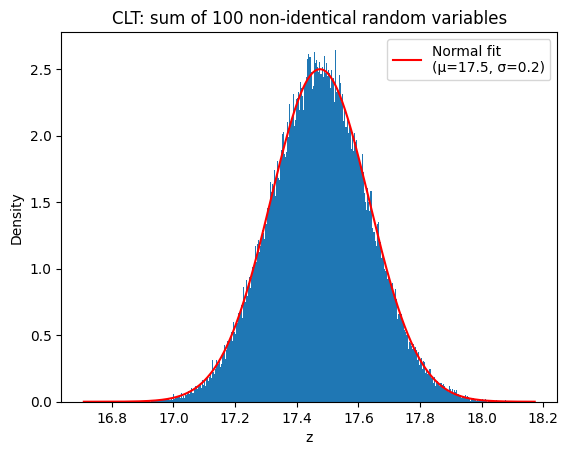

In [11]:
d = gen_clt_plot(100, 100000, 500)